In [ ]:
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import metrics

In [ ]:
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving team6_test_preds.pkl to team6_test_preds.pkl
User uploaded file "team6_test_preds.pkl" with length 48658 bytes


In [ ]:
!pip3 install pickle5
import pickle5 as pickle

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.1/132.1 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pickle5: filename=pickle5-0.0.11-cp310-cp310-linux_x86_64.whl size=255312 sha256=fd01d88b3633e6dd8f54075569ee03feec1064f59fdca2eea2d3ced16d5a2262
  Stored in directory: /root/.cache/pip/wheels/7d/14/ef/4aab19d27fa8e58772be5c71c16add0426acf9e1f64353235c
Successfully built pickle5


In [ ]:
pd.read_pickle('/content/team6_test_preds.pkl')

,0,1,2,3,4
0,0.010394,0.004931,0.027728,0.936143,0.008735
1,0.383605,0.347923,0.135321,0.008644,0.126230
2,0.401242,0.154052,0.241005,0.030241,0.187080
3,0.231229,0.054946,0.199564,0.344693,0.211631
4,0.411816,0.151382,0.216552,0.024048,0.199127
...,...,...,...,...,...
995,0.133064,0.386992,0.183356,0.021098,0.321365
996,0.275951,0.348446,0.159126,0.020636,0.210005
997,0.345696,0.394555,0.149720,0.016436,0.124063
998,0.146889,0.202506,0.255787,0.033669,0.350158


In [ ]:
stage_dict = {0:'Arousal', 1:'NREM1', 2:'NREM2', 3:'NREM3', 4:'REM'}
with open('/content/team6_test_preds.pkl', 'rb') as f:
    test_pred = pickle.load(f)
test_predict = test_pred.idxmax(axis=1)
test_labels = pd.read_pickle('TEST_LABELS.xz')
test_labels_one_hot = pd.DataFrame(np.eye(5)[test_labels.values.reshape(1000).astype(int)])
acc=0
for i, j in enumerate(test_predict):
  if test_labels['Label'][i]==j:
    acc+=1
print(acc/len(test_labels))

0.527


In [ ]:
test_pred.shape

(1000, 5)

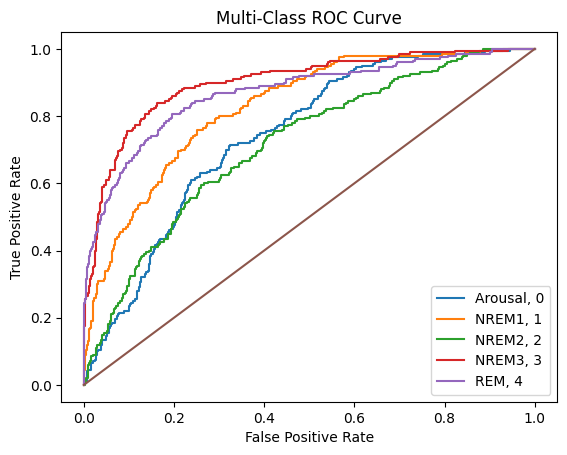

In [ ]:
fpr = {}
tpr = {}
roc_auc = {}
for i in range(5):
  fpr[i], tpr[i], _ = metrics.roc_curve(test_labels_one_hot.iloc[:, i], test_pred.iloc[:, i])
  roc_auc[i] = metrics.auc(fpr[i], tpr[i])
  plt.plot(fpr[i], tpr[i], label = stage_dict[i] + ', ' + str(i))
plt.plot([0, 1], [0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve')
plt.legend()
plt.show()

fpr["micro"], tpr["micro"], _ = metrics.roc_curve(test_labels_one_hot.values.ravel(), test_pred.values.ravel())
roc_auc = metrics.auc(fpr["micro"], tpr["micro"])

In [ ]:
y_true = []
y_pred = []
for i in range(1000):
  if test_predict.iloc[i]==0:
    y_pred.append(1)
  else:
    y_pred.append(-1)
  if test_labels.iloc[i][0]==0:
    y_true.append(1)
  else:
    y_true.append(-1)
mcc = metrics.matthews_corrcoef(y_true, y_pred)

In [ ]:
print(roc_auc, mcc)

0.818494 0.28094832006269854
